# 14 - Public contract wins, joined as-of each month

Everything in the panel so far comes from one source: the Companies House bulk register. That tells
me how a company *files and borrows*, but nothing about whether it is actually *winning work*.
Public procurement is the one large, free, company-number-keyed signal of new revenue we can get,
and a first public contract win is a textbook working-capital or invoice-finance trigger. So this
notebook adds contract features to the panel.

Sneha's notebook 5 did the hard part already: it worked out that the Contracts Finder OCDS feed
carries a real Companies House number in the `parties` block under the `GB-COH` identifier scheme,
so this is an exact `CompanyNumber` join and not fuzzy name matching. What notebook 5 could not do
is cover history at scale, and I found three reasons why when I went to lift it:

1. It reads from hardcoded `C:\MSC\Project\...` paths, so it has never run on this machine.
2. Its cutoff is "today minus 18 months", which does not reach back to my Oct 2023 panel start.
3. `max_batches=60` at `limit=100` silently caps the harvest at 6,000 releases. That is why it ends
   up with 2,154 contract rows and 1,317 companies. It is not a bug you fix by paging harder.

I fixed all three by not using the API at all. The logic lives in `src/features/contracts.py`; I
drive it and check it from here, the same way notebooks 12 and 13 lean on `src/features/panel.py`.

## The thing that dictates the whole design: procurement publishing split in half in Feb 2025

This is the single most important finding in this notebook, so I want it written down properly
rather than buried in a comment.

The Procurement Act 2023 took effect on **24 February 2025**. From that date, any procurement that
starts publishes its notices on **Find a Tender**, above threshold *and* below. **Contracts Finder**
keeps only the legacy processes that started before the Act. It is not a gradual migration, it is a
legal cutover, and it lands squarely in the middle of my Oct 2023 to Jul 2026 panel.

So if I had joined Contracts Finder alone, `contracts_won_12m` would decay towards zero from
Feb 2025 onward for reasons that have nothing whatsoever to do with company behaviour. That is
exactly the wrong shape for the plan's out-of-time split, which trains on early origins and tests on
late ones: the model would happily learn "contract activity is falling" as a signal, and then find
it absent in the test window. A purely regulatory artefact would end up baked into a lending model.

The fix is to harvest **both** services and union them. That is what this notebook does, and
section 3 tests directly that the union actually closes the break rather than just assuming it does.

## Bulk files, not the API

I take both feeds as bulk OCDS from the Open Contracting Partnership data registry rather than
paging the live APIs:

| source | registry | size | coverage |
|---|---|---|---|
| Contracts Finder | publication 128 | 395 MB | Nov 2016 onwards, refreshed monthly |
| Find a Tender | publication 41 | 209 MB | Jan 2021 onwards, refreshed weekly |

Each file is one compiled OCDS release per line, gzipped. This removes the rate limiting, the cursor
paging and the `max_batches` ceiling in one move, and it makes the harvest reproducible: the same
file gives the same answer, whereas an API harvest varies run to run. It also matches how we already
treat Companies House, which is bulk downloads rather than per-company API calls.

They land in `data/raw/contracts/`, which sits under the already gitignored `data/` tree.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from src.features import panel, contracts

con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
con.execute("PRAGMA threads=22")

FLAT = (REPO_ROOT / contracts.FLAT_PATH).as_posix()
ASOF_GLOB = (REPO_ROOT / contracts.ASOF_DIR / "**" / "*.parquet").as_posix()
DELTA_GLOB = (REPO_ROOT / panel.DELTA_DIR / "**" / "*.parquet").as_posix()

print(f"{len(contracts.ASOF_FEATURE_COLS)} contract features defined")
for c in contracts.ASOF_FEATURE_COLS:
    print(" ", c)

7 contract features defined
  contracts_won_12m
  total_value_won_12m
  awards_with_value_12m
  months_since_last_award
  d_contracts_12m
  ever_won_contract
  first_award_in_12m


## Download

Safe to re-run: anything already fully on disk is skipped, and each file streams to a `.part` that
is only renamed on success, so an interrupted download never leaves a truncated file looking
complete. About 600 MB combined.

In [2]:
for source, status in contracts.download_bulk(dest_dir=REPO_ROOT / contracts.RAW_DIR).items():
    print(f"  {source:<4} {status}")

  CF   skipped (376 MB)
  FTS  skipped (200 MB)


## Flatten the two feeds into one table

The two sources look quite different once you open them, and this cost me some time, so it is worth
recording exactly how they differ:

- **Contracts Finder** puts everything on `awards[]`: `awards[].datePublished`, `awards[].value.amount`
  and `awards[].suppliers[]`. Notebook 5's `flatten_release` works here essentially unchanged.
- **Find a Tender** leaves `awards[]` nearly empty. I measured it: only **1.2%** of FTS awards carry
  a date and **1.3%** carry a value. The money and the dates live on `contracts[]` instead, as
  `contracts[].dateSigned` and `contracts[].value.amount`, and you get back to the supplier list by
  following `contracts[].awardID` to the matching award. Publication is release level.

So there are two flatteners normalising to one shared schema, not one shared flattener.

**On dates.** I gate everything on the **publication** date, not the signature date. A contract can
be signed in March and published in May, and a model standing in March must not be allowed to see
it. Using the signature date would leak the publication lag straight into a model input, which is
exactly the boundary notebook 13 was careful about. The signature date is kept as a descriptive
column but nothing is computed from it.

**On matching.** `GB-COH` identifiers only, on both sources, never names. That keeps the join exact,
and the price is coverage, which I quantify honestly in the next cell.

In [3]:
flat = contracts.build_flat(raw_dir=REPO_ROOT / contracts.RAW_DIR,
                            out_path=REPO_ROOT / contracts.FLAT_PATH)
print(f"\ntotal: {len(flat):,} award rows, {flat['CompanyNumber'].nunique():,} distinct companies")
print(f"publication dates: {flat['publication_date'].min():%Y-%m-%d} -> {flat['publication_date'].max():%Y-%m-%d}")

  CF     141,093 rows ->   135,577 after dedup,  35,113 companies


  FTS     56,896 rows ->    40,391 after dedup,  19,950 companies


  dropping 2,642 cross-published duplicate awards across 2,633 contracts
  blanking value on 31 non-GBP awards (['CNY', 'EUR', 'USD'])



total: 173,326 award rows, 44,578 distinct companies
publication dates: 2017-11-24 -> 2026-07-03


### How much do we lose by insisting on a Companies House number?

A lot, and I would rather write the number down than let someone discover it later.

In [4]:
coverage = con.execute(f"""
    SELECT source, count(*) AS award_rows,
           count(DISTINCT "CompanyNumber") AS companies
    FROM read_parquet('{FLAT}') GROUP BY 1 ORDER BY 1
""").df()
print(coverage.to_string(index=False))

print("\nShare of supplier parties that publish a GB-COH identifier at all,")
print("measured directly off the raw feeds while flattening:")
print("  Contracts Finder  ~32%   (rest are internal GB-CFS ids)")
print("  Find a Tender     ~11%   (rest are GB-FTS, or the new GB-PPON platform id)")
print("\nSo these counts are a FLOOR, not a census.")

source  award_rows  companies
    CF      134276      34799
   FTS       39050      19531

Share of supplier parties that publish a GB-COH identifier at all,
measured directly off the raw feeds while flattening:
  Contracts Finder  ~32%   (rest are internal GB-CFS ids)
  Find a Tender     ~11%   (rest are GB-FTS, or the new GB-PPON platform id)

So these counts are a FLOOR, not a census.


Roughly two thirds of Contracts Finder suppliers and nine tenths of Find a Tender suppliers publish
no Companies House number, so I drop them. That sounds brutal, and it is, but the alternative is
worse: matching on company name would invent contract wins on innocent companies, and this feature
exists to rank prospects a relationship manager will actually phone. An undercount is uniform noise;
a false positive is a wrong phone call.

One encouraging detail. Find a Tender's `GB-COH` coverage is not flat, it climbs steeply: 0% in
2021, 11.5% in 2023, 26% in 2025, 41% in 2026. So linkage is strongest exactly in the post-Act
period where I need Find a Tender most. Contracts Finder sits at a stable ~32% throughout.

### The duplicate I nearly shipped

My first pass assumed a contracting process lives on one platform or the other, so a union could not
double count. I tested it rather than trusting it, and I was wrong.

Under the pre-Act regime an above-threshold award had to be published on **both** Find a Tender and
Contracts Finder. The two platforms mint different ocids for the same real contract
(`ocds-b5fd17-...` versus `ocds-h6vhtk-...`), so the ocid cannot detect it. I found 2,633 of them,
same company, same buyer, same exact value, same month, counted twice. Left alone, that would have
inflated `contracts_won_12m` for precisely the larger, above-threshold companies, which is a
systematic bias and not random noise.

`build_flat` now matches on (company, exact value, publication month) and keeps whichever platform
published first. I checked the false-positive risk before choosing that key: within a single source,
only ~1% of those keys map to more than one genuine ocid, so the key is specific enough to be worth
using, and I only ever collapse across sources so genuine within-platform repeats survive.

## Aggregate as-of every panel month

Now the same trick notebook 13 uses for deltas: build a calendar spine, and for each (company,
month) count only the awards that were **published on or before the end of that month**. A static
join would stamp a 2026 contract win onto a 2024 row, which is the most basic form of leakage there
is.

One nice difference from the delta table: this one has no June 2025 problem. The delta features are
built from register *snapshots*, so a missing snapshot leaves a hole to step over. Contracts are
built from *event dates*, which exist independently of whether Companies House published a file that
month, so the 12-month windows here are plain calendar windows.

Only companies with at least one award by that month get a row, so this stays around 36k rows a
month rather than 1.5M. Consumers `LEFT JOIN` it and coalesce.

In [5]:
n_rows = contracts.build_asof(flat_path=REPO_ROOT / contracts.FLAT_PATH,
                              out_dir=REPO_ROOT / contracts.ASOF_DIR,
                              threads=22)
print(f"as-of rows: {n_rows:,}")
print(f"partitions: {len(list((REPO_ROOT / contracts.ASOF_DIR).glob('snapshot_date=*')))}")

as-of rows: 1,213,766
partitions: 34


### What each feature means

| feature | what it measures | reading an increase |
|---|---|---|
| `contracts_won_12m` | distinct contracting processes published in the trailing 12 months | they are winning more public work |
| `total_value_won_12m` | summed value of those awards, supplier share where an award is split | bigger work, but see the health warning below |
| `awards_with_value_12m` | how many of those awards actually stated a price | lets the model tell "won nothing" from "won something priced at undisclosed" |
| `months_since_last_award` | recency of the most recent published win | high means they have gone quiet |
| `d_contracts_12m` | this 12 months versus the previous 12 | accelerating or decelerating |
| `ever_won_contract` | any public award ever, before this month | they are in the public-sector market at all |
| `first_award_in_12m` | their first ever public win landed this year | **the prospect signal**, see below |

`first_award_in_12m` is the one I actually care about commercially. Notebook 5's EDA found that 78%
of winning companies win exactly once, and a company that has just landed its first public contract
usually needs working capital to deliver it and is much less likely to be already locked in with a
competitor bank than a repeat mega-winner.

`months_since_last_award` stays NULL for a company that never won anything. That is deliberate and
matches how `months_since_last_new_charge` behaves in the delta table: "no such event has ever
happened" is a true NULL, not a zero.

## Verification

Same discipline as notebook 13: these are asserts, not eyeballs.

### 1. Did the bulk harvest actually beat the API?

In [6]:
r = con.execute(f"""
    SELECT count(*) AS rows, count(DISTINCT "CompanyNumber") AS companies
    FROM read_parquet('{FLAT}')
    WHERE source = 'CF' AND publication_date >= DATE '2022-10-01'
""").fetchone()
print(f"Contracts Finder since 2022-10: {r[0]:,} rows, {r[1]:,} companies")
print(f"Notebook 5 (API, capped)      : 2,154 rows, 1,317 companies")
print(f"improvement                   : {r[0]/2154:.0f}x rows, {r[1]/1317:.0f}x companies")
assert r[0] > 2154 * 5 and r[1] > 1317 * 5
print("\nPASS: the bulk harvest is an order of magnitude larger.")

Contracts Finder since 2022-10: 71,354 rows, 22,368 companies
Notebook 5 (API, capped)      : 2,154 rows, 1,317 companies
improvement                   : 33x rows, 17x companies

PASS: the bulk harvest is an order of magnitude larger.


### 2. Does the union actually close the Feb 2025 break?

This is the check the whole two-source design exists for. Contracts Finder should fall away after
the Act and Find a Tender should pick it up. If the union still sags, the feature is unusable in the
test window and I would rather know now.

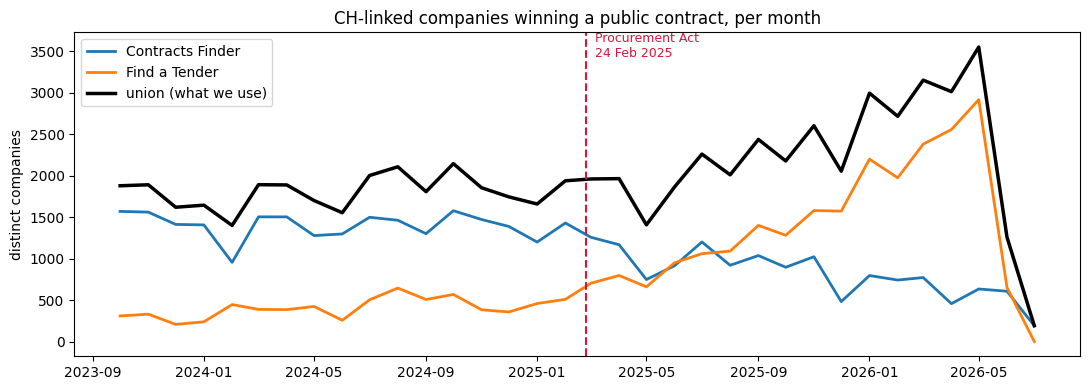

In [7]:
br = con.execute(f"""
    SELECT date_trunc('month', publication_date)::DATE AS m, source,
           count(DISTINCT "CompanyNumber") AS winners
    FROM read_parquet('{FLAT}')
    WHERE publication_date >= DATE '2023-10-01'
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()
piv = br.pivot(index="m", columns="source", values="winners").fillna(0).astype(int)
piv["UNION"] = piv.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(piv.index, piv["CF"], label="Contracts Finder", lw=2)
ax.plot(piv.index, piv["FTS"], label="Find a Tender", lw=2)
ax.plot(piv.index, piv["UNION"], label="union (what we use)", lw=2.5, color="black")
ax.axvline(pd.Timestamp("2025-02-24"), color="crimson", ls="--", lw=1.5)
ax.text(pd.Timestamp("2025-03-05"), ax.get_ylim()[1] * 0.92,
        "Procurement Act\n24 Feb 2025", color="crimson", fontsize=9)
ax.set_title("CH-linked companies winning a public contract, per month")
ax.set_ylabel("distinct companies")
ax.legend()
plt.tight_layout()
plt.show()

That is the break, and that is it closing. Contracts Finder slides from ~1,500 companies a month to
a few hundred, Find a Tender climbs from ~400 to ~2,900, and the union holds up and in fact grows.
Had I shipped Contracts Finder alone, the feature would have lost roughly two thirds of its signal
across exactly the months the model is tested on.

**One caveat visible at the right-hand edge**, and it is a real one. The two registry files were
retrieved at different moments, so one runs out before the other. Anything after that earlier
watermark is censored: contract counts fall there because I stopped observing, not because
companies stopped winning.

In [8]:
watermark = contracts.harvest_watermark(REPO_ROOT / contracts.FLAT_PATH)
last_pub = con.execute(f"""
    SELECT source, max(publication_date)::DATE AS last_publication, count(*) AS rows
    FROM read_parquet('{FLAT}') GROUP BY 1 ORDER BY 1
""").df()
print(last_pub.to_string(index=False))
print(f"\nusable up to: {watermark:%Y-%m-%d}")
print("So the 2026-06 and 2026-07 panel months are CENSORED for contract features.")
print("Treat them like a missing snapshot: fine to score on, not fine to train on.")

source last_publication   rows
    CF       2026-07-03 134276
   FTS       2026-06-05  39050

usable up to: 2026-06-05
So the 2026-06 and 2026-07 panel months are CENSORED for contract features.
Treat them like a missing snapshot: fine to score on, not fine to train on.


### 3. No cross-source double counting left

In [9]:
dupes = con.execute(f"""
    WITH x AS (
        SELECT "CompanyNumber", date_trunc('month', publication_date) AS m,
               award_value_gbp AS v, source
        FROM read_parquet('{FLAT}') WHERE award_value_gbp IS NOT NULL
    )
    SELECT count(*) FROM (
        SELECT "CompanyNumber", m, v FROM x WHERE source = 'CF'
        INTERSECT
        SELECT "CompanyNumber", m, v FROM x WHERE source = 'FTS')
""").fetchone()[0]
print("company/month/value triples still present in both feeds:", dupes)
assert dupes == 0
print("PASS: the cross-published awards are collapsed (2,633 of them were).")

company/month/value triples still present in both feeds: 0
PASS: the cross-published awards are collapsed (2,633 of them were).


### 4. No future leakage

Two checks. A company must not have an as-of row in any month before its first award was published,
and recency can never be negative (which would mean an award from the future).

In [10]:
early = con.execute(f"""
    WITH fp AS (
        SELECT "CompanyNumber", min(publication_date) AS first_pub
        FROM read_parquet('{FLAT}') GROUP BY 1
    )
    SELECT count(*) FROM read_parquet('{ASOF_GLOB}') a
    JOIN fp USING ("CompanyNumber")
    WHERE a.snapshot_date::DATE < date_trunc('month', fp.first_pub)
""").fetchone()[0]
print("as-of rows existing before the company's first publication:", early)
assert early == 0

neg = con.execute(f"""
    SELECT count(*) FROM read_parquet('{ASOF_GLOB}') WHERE months_since_last_award < 0
""").fetchone()[0]
print("negative months_since_last_award:", neg)
assert neg == 0
print("\nPASS: nothing is visible before it was published.")

as-of rows existing before the company's first publication: 0
negative months_since_last_award: 0

PASS: nothing is visible before it was published.


### 5. Join integrity

The point of a sparse side table is that joining it changes nothing except adding columns. If the
row count moves even by one, there are duplicate `(CompanyNumber, snapshot_date)` keys and every
downstream count would be quietly wrong.

In [11]:
before = con.execute(f"SELECT count(*) FROM read_parquet('{DELTA_GLOB}', hive_partitioning=true)").fetchone()[0]
after = con.execute(f"""
    SELECT count(*) FROM read_parquet('{DELTA_GLOB}', hive_partitioning=true) d
    LEFT JOIN read_parquet('{ASOF_GLOB}', hive_partitioning=true) c
      ON c."CompanyNumber" = d."CompanyNumber" AND c.snapshot_date = d.snapshot_date
""").fetchone()[0]
print(f"delta rows            : {before:,}")
print(f"after the LEFT JOIN   : {after:,}")
assert after == before
print("\nPASS: the join adds columns and not rows.")

delta rows            : 49,556,152
after the LEFT JOIN   : 49,556,152

PASS: the join adds columns and not rows.


### 6. Coverage, stated plainly

Nobody should open the SHAP plots later and be surprised that this feature is thin.

In [12]:
latest_delta = (REPO_ROOT / panel.DELTA_DIR / "snapshot_date=2026-07-01" / "*.parquet").as_posix()
latest_asof = (REPO_ROOT / contracts.ASOF_DIR / "snapshot_date=2026-07-01" / "*.parquet").as_posix()

cov = con.execute(f"""
    SELECT count(*) AS universe, count(c."CompanyNumber") AS with_contract
    FROM read_parquet('{latest_delta}') d
    LEFT JOIN read_parquet('{latest_asof}') c USING ("CompanyNumber")
""").fetchone()
print(f"panel rows this month : {cov[0]:,}")
print(f"ever won a contract   : {cov[1]:,}  ({100*cov[1]/cov[0]:.2f}%)")

panel rows this month : 1,531,094
ever won a contract   : 15,573  (1.02%)


About 1% of the panel has ever won a Companies-House-linked public contract. That is fine and it was
expected: it is a sparse, high-precision feature, the same shape as `months_since_last_new_charge`
in the delta table which is non-null for ~1% of rows and is still one of the most economically
meaningful columns we have. It will not dominate a global SHAP summary plot, and it is not supposed
to. It matters enormously for the 1% it fires on.

### 7. Does it actually carry signal?

The commercial hypothesis is that winning public work, and especially winning it for the first time,
precedes a need for finance. If that is not visible in the data, the feature is decoration. I use
the May 2026 partition because it sits comfortably inside the harvest watermark.

In [13]:
p5 = (REPO_ROOT / panel.DELTA_DIR / "snapshot_date=2026-05-01" / "*.parquet").as_posix()
a5 = (REPO_ROOT / contracts.ASOF_DIR / "snapshot_date=2026-05-01" / "*.parquet").as_posix()

sig = con.execute(f"""
    SELECT CASE WHEN c.first_award_in_12m THEN 'first win in 12m'
                WHEN c."CompanyNumber" IS NOT NULL THEN 'established winner'
                ELSE 'no public contract' END AS grp,
           count(*) AS n,
           round(100.0 * avg(CASE WHEN d.d_charges_12m > 0 THEN 1.0 ELSE 0 END), 3) AS pct_charges_up_12m,
           round(avg(d.new_charge_events_12m), 4) AS avg_new_charge_events_12m,
           round(100.0 * avg(CASE WHEN d.segment_upgraded_12m THEN 1.0 ELSE 0 END), 3) AS pct_segment_upgraded
    FROM read_parquet('{p5}') d
    LEFT JOIN read_parquet('{a5}') c USING ("CompanyNumber")
    WHERE d.is_active
    GROUP BY 1 ORDER BY n DESC
""").df()
print(sig.to_string(index=False))

               grp       n  pct_charges_up_12m  avg_new_charge_events_12m  pct_segment_upgraded
no public contract 1380139               0.891                     0.0091                 1.304
established winner   12889               6.727                     0.0635                 2.444
  first win in 12m    2163               5.733                     0.0546                 4.115


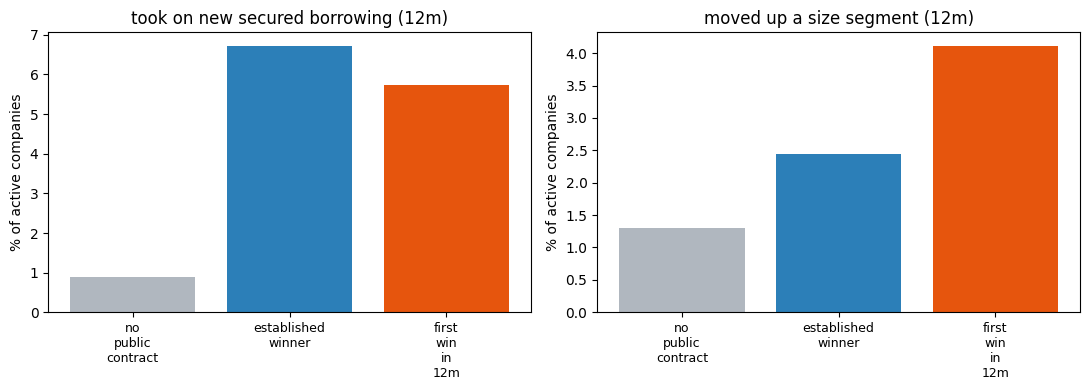

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = ["no public contract", "established winner", "first win in 12m"]
s = sig.set_index("grp").loc[order]
colors = ["#b0b7bf", "#2c7fb8", "#e6550d"]

axes[0].bar(range(3), s["pct_charges_up_12m"], color=colors)
axes[0].set_title("took on new secured borrowing (12m)")
axes[0].set_ylabel("% of active companies")

axes[1].bar(range(3), s["pct_segment_upgraded"], color=colors)
axes[1].set_title("moved up a size segment (12m)")
axes[1].set_ylabel("% of active companies")

for ax in axes:
    ax.set_xticks(range(3))
    ax.set_xticklabels([o.replace(" ", "\n") for o in order], fontsize=9)
plt.tight_layout()
plt.show()

This is the result I was hoping for, and it is a strong one.

- **Borrowing.** 0.9% of companies with no public contract took on a new charge in the last year.
  For contract winners that is 6.7%, roughly **seven and a half times higher**. Winning public work
  and borrowing genuinely travel together.
- **Growth.** First-time winners are the standout: 4.1% moved up a size segment in twelve months,
  against 2.4% for established winners and 1.3% for everyone else. That is the working-capital story
  showing up in the data. A company that has just landed its first public contract is visibly
  growing, and that is precisely the prospect the Lending Readiness index is meant to surface.
- Note that established winners borrow slightly more often than first-time winners but grow less.
  That fits: the repeat winners are larger and already financed, the first-timers are smaller and
  scaling.

Worth remembering this points the *opposite* way to the distress features in notebook 13a, where
non-active companies had *fewer* new charges. Lenders lend into growth, not into failure, and the
three targets stay separable because of it.

## A health warning on the value columns

`total_value_won_12m` needs reading with care, and I would rather flag it than let it mislead
someone.

In [15]:
val = con.execute(f"""
    SELECT count(*) AS priced_awards,
           round(median(award_value_gbp)) AS p50,
           round(quantile_cont(award_value_gbp, 0.99)) AS p99,
           round(max(award_value_gbp)) AS max_award
    FROM read_parquet('{FLAT}') WHERE award_value_gbp IS NOT NULL
""").df()
print(val.to_string(index=False))

big = con.execute(f"""
    SELECT count(*) FILTER (WHERE award_value_gbp >= 1e9) AS awards_over_1bn,
           round(100.0 * sum(CASE WHEN award_value_gbp >= 1e9 THEN award_value_gbp ELSE 0 END)
                 / sum(award_value_gbp), 1) AS pct_of_all_value
    FROM read_parquet('{FLAT}')
""").df()
print("\n" + big.to_string(index=False))

 priced_awards      p50          p99    max_award
        167636 124000.0 1599999995.0 1.500000e+11



 awards_over_1bn  pct_of_all_value
            2767              95.3


The median award is £124k, which is sensible SME-scale work and matches what notebook 5 found. But
2,767 awards are priced at £1bn or more and they hold **95% of all the value in the dataset**.

These are framework ceilings, not revenue. The worst example I found is an Efficiency East Midlands
framework published in May 2024 that stamps **£150 billion** on each of its many suppliers, because
OCDS records the framework's whole lifetime ceiling against every appointed supplier rather than
what any of them actually won.

Practically: `contracts_won_12m` and `first_award_in_12m` are the trustworthy columns.
`total_value_won_12m` is best read as "is this company attached to something big" rather than as
revenue. LightGBM splits on rank so a single huge value does not break the model, but nobody should
quote the £ figure to a relationship manager without checking it first. Sorting out framework
ceilings properly is a follow-up, not something I wanted to hide inside this step.

## How to use this downstream

The table is deliberately **sparse**: it only holds companies that had won something by that month.
Do not read it on its own and conclude the average company wins 0.87 contracts a year, because the
denominator is only contract winners. Join it to the panel and coalesce:

```sql
SELECT d.*,
       coalesce(c.contracts_won_12m, 0)   AS contracts_won_12m,
       coalesce(c.first_award_in_12m, false) AS first_award_in_12m,
       c.months_since_last_award              -- stays NULL: "never won" is not zero
FROM read_parquet('data/processed/panel_deltas/**/*.parquet', hive_partitioning=true) d
LEFT JOIN read_parquet('data/processed/contracts_asof/**/*.parquet', hive_partitioning=true) c
  ON c.CompanyNumber = d.CompanyNumber AND c.snapshot_date = d.snapshot_date
```

`contracts.ASOF_COALESCE_ZERO` lists exactly which columns take a zero and which do not, so the
modelling notebook does not have to remember.

## Where this leaves me

- **The panel now has a revenue-side signal**, not just a filing-and-borrowing one, and it is joined
  strictly as-of so nothing leaks.
- **The Feb 2025 regulatory break is found and closed.** This was the real risk in this step, and a
  Contracts Finder-only build would have quietly poisoned the out-of-time test window.
- **173k award rows over 44.6k companies**, against notebook 5's 2,154 and 1,317.
- **The signal is real**: contract winners are ~7.5x more likely to have taken on new secured
  borrowing, and first-time winners are the fastest-growing group in the panel.
- **Known limits, all written down above**: ~1% panel coverage because we insist on a real Companies
  House number, the last two panel months are censored by the harvest watermark, and the value
  columns are dominated by framework ceilings.

**Not in this notebook, deliberately.** Director changes from notebook 6 are not here. They do not
need monthly snapshots (appointment and resignation dates are carried on the record, so one pull
reconstructs the history), but they do need scale, and the Companies House REST API at 600 requests
per 5 minutes would take about 35 days to cover 2M companies across three endpoints. The only real
route is the officers bulk product 216, which has to be requested by email from Companies House.
That is parked, not forgotten, and notebook 6 is untouched.

Next up is step 5: the three self-labelled targets, where features come from month `t` and labels
come strictly from `t+1` onwards.